In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings("ignore")


import mlflow
import mlflow.sklearn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

pd.set_option("display.width", 130)


sns.set(style="whitegrid")


In [2]:
df = pd.read_csv('data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [4]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 1081


In [5]:
df[df.duplicated() ==True][:10]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
223,145.0,-2.419486,1.949346,0.552998,0.982710,-0.284815,2.411200,-1.398537,-0.188922,0.675695,...,1.213390,-1.238354,0.007191,-1.724175,0.239721,-0.313607,-0.187431,0.119472,6.74,0
1178,919.0,0.904289,-0.538055,0.396058,0.500680,-0.864473,-0.657199,0.027231,-0.029473,0.265447,...,-0.099460,-0.597579,-0.048666,0.551824,0.182934,0.402176,-0.081357,0.027252,158.00,0
1180,919.0,1.207596,-0.036860,0.572104,0.373148,-0.709633,-0.713698,-0.181105,0.011277,0.283940,...,-0.194591,-0.514717,0.089714,0.543768,0.240581,0.418921,-0.051693,-0.000085,1.00,0
1382,1074.0,-2.248488,-0.195670,0.026949,-0.525780,-0.238759,-0.033359,0.162196,0.928520,-0.424215,...,-0.032208,-0.745757,-0.243193,-0.821633,-0.030402,0.335838,-0.286998,-0.243768,158.00,0


In [5]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(283726, 31)

In [6]:
mlflow.set_tracking_uri("sqlite:///mlflow_fraud.db")
mlflow.set_experiment("classification_for_credit_card_fraud")

print("Tracking URI:", mlflow.get_tracking_uri())
print("Active experiment:", mlflow.get_experiment_by_name("classification_for_credit_card_fraud").name)


Tracking URI: sqlite:///mlflow_fraud.db
Active experiment: classification_for_credit_card_fraud


In [8]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17',
       'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class'],
      dtype='object')

In [7]:
X = df.drop(columns=['Class'])
y = df['Class']

In [8]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [9]:
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(Class
 0    0.998335
 1    0.001665
 Name: proportion, dtype: float64,
 Class
 0    0.998326
 1    0.001674
 Name: proportion, dtype: float64)

In [10]:
raw_cols = ['Time', 'Amount']
pca_cols = [f'V{i}' for i in range(1, 29)]


num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


processor = ColumnTransformer([
    ('num', num_pipeline, raw_cols),
    ('pca_pass', 'passthrough', pca_cols)
])



In [13]:
processor.fit(x_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('pca_pass', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [14]:
x_train_transformed = processor.transform(x_train)
x_test_transformed = processor.transform(x_test)

In [11]:
scale_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

In [23]:
classifier = {
    'Logistic Regression' : (LogisticRegression, {"max_iter":1000}),
    'Naive Bayes': (GaussianNB, {}),
    'Decision Tree': (DecisionTreeClassifier, {"random_state": 42}),
    'KNN': (KNeighborsClassifier, {}),
    'Random Forest': (RandomForestClassifier, {"random_state":42}),
    'XGBoost' : (XGBClassifier, {"scale_pos_weight":1, "eval_metric":'aucpr', "n_estimators":200}),
    'CatBoost': (CatBoostClassifier, {"scale_pos_weight":1, "eval_metric":'AUC', "verbose":0})
}

In [17]:
run_ids={}

for name, (ModelClass, params) in classifier.items():
    with mlflow.start_run(run_name=name) as run:
        mlflow.set_tag('algorithm', name)
        mlflow.log_params(params)
        print(params)
        model = ModelClass(**params)
        model.fit(x_train_transformed, y_train)

        preds = model.predict(x_test_transformed)
        proba = model.predict_proba(x_test_transformed)[:,1] if hasattr(model, 'predict_proba') else None

        metrics = {
            "accuracy": accuracy_score(y_test, preds),
            "precision": precision_score(y_test, preds),
            "recall": recall_score(y_test, preds),
            "F1": f1_score(y_test, preds)
        }

        if proba is not None:
            metrics['roc_auc'] = roc_auc_score(y_test, proba)
        
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(model, name='model',input_example=x_train_transformed[:2], skops_trusted_types=[
        "xgboost.core.Booster", 
        "xgboost.sklearn.XGBClassifier",
        "catboost.core.CatBoostClassifier",
        "catboost.CatBoostClassifier"
    ])

        run_ids[name] = run.info.run_id
        print(f"{name:22s} run_id={run.info.run_id}  f1={metrics['F1']:.3f}  acc={metrics['accuracy']:.3f}") 

{'max_iter': 1000}


2026/07/17 22:07:03 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 22:07:06 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 22:07:06 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/17 22:07:06 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/17 22:07:06 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/17 22:07:07 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Logistic Regression    run_id=dec2b316bbda4d00937b8b22ce668c2e  f1=0.696  acc=0.999
{}


2026/07/17 22:07:08 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 22:07:08 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 22:07:08 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/17 22:07:08 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/17 22:07:08 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/17 22:07:09 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Naive Bayes            run_id=6ba7fe045d9449968f2a242726581c0a  f1=0.108  acc=0.978
{'random_state': 42}


2026/07/17 22:07:26 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 22:07:26 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 22:07:26 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/17 22:07:26 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/17 22:07:26 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/17 22:07:27 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Decision Tree          run_id=af37e8cf091b4622b518bcc382a60b1b  f1=0.706  acc=0.999
{}


2026/07/17 22:08:24 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 22:08:25 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 22:08:25 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/17 22:08:25 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/17 22:08:25 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/17 22:08:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


KNN                    run_id=34e63566bb624ba8bc7966c9454fac75  f1=0.817  acc=0.999
{}


2026/07/17 22:10:03 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 22:10:03 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 22:10:03 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/17 22:10:03 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/17 22:10:03 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/17 22:10:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


SVM                    run_id=77b74cad96b146b296457426bb6ff723  f1=0.761  acc=0.999
{'random_state': 42}


2026/07/17 22:13:18 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 22:13:18 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 22:13:18 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/17 22:13:18 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/17 22:13:18 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/17 22:13:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Random Forest          run_id=9f8541199456433980a4e80c829e0270  f1=0.836  acc=1.000
{'scale_pos_weight': np.float64(599.4761904761905), 'eval_metric': 'aucpr', 'n_estimators': 200}


2026/07/17 22:13:23 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 22:13:23 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 22:13:23 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/17 22:13:23 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/17 22:13:23 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/17 22:13:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


XGBoost                run_id=966eb4f146024ddbae8fe0ff9a9631f4  f1=0.860  acc=1.000
{'scale_pos_weight': np.float64(599.4761904761905), 'eval_metric': 'AUC', 'verbose': 0}


2026/07/17 22:13:52 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 22:13:52 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/17 22:13:52 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/17 22:13:53 INFO mlflow.utils.uv_utils: Exported 179 dependencies via uv
2026/07/17 22:13:53 INFO mlflow.utils.environment: Successfully exported 179 requirements from uv project. Skipping package capture based inference.
2026/07/17 22:13:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


CatBoost               run_id=09046702d5bc47228da29cf1ac8e24fc  f1=0.813  acc=0.999


In [88]:
runs_df.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time', 'end_time', 'metrics.roc_auc', 'metrics.precision',
       'metrics.accuracy', 'metrics.recall', 'metrics.F1', 'params.scale_pos_weight', 'params.eval_metric', 'params.verbose',
       'params.n_estimators', 'params.random_state', 'params.max_iter', 'params.c', 'tags.mlflow.source.name', 'tags.algorithm',
       'tags.mlflow.user', 'tags.mlflow.source.type', 'tags.mlflow.runName'],
      dtype='object')

In [18]:
experiment = mlflow.get_experiment_by_name("classification_for_credit_card_fraud")
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

metric_cols = [c for c in runs_df.columns if c.startswith("metrics.")]

comparison = runs_df[["run_id", "tags.algorithm"] + metric_cols].sort_values(
    "metrics.F1", ascending=False
).reset_index(drop=True)

comparison.columns= [c.replace("metrics.", "") for c in comparison.columns]
comparison

,run_id,tags.algorithm,accuracy,precision,recall,roc_auc,F1
0,966eb4f146024ddbae8fe0ff9a9631f4,XGBoost,0.999577,0.961039,0.778947,0.972716,0.860465
1,9f8541199456433980a4e80c829e0270,Random Forest,0.999524,0.985714,0.726316,0.919092,0.836364
2,34e63566bb624ba8bc7966c9454fac75,KNN,0.999471,0.971014,0.705263,0.899889,0.817073
3,09046702d5bc47228da29cf1ac8e24fc,CatBoost,0.999383,0.826087,0.800000,0.963476,0.812834
4,77b74cad96b146b296457426bb6ff723,SVM,0.999348,0.983333,0.621053,NaN,0.761290
5,af37e8cf091b4622b518bcc382a60b1b,Decision Tree,0.999031,0.717391,0.694737,0.847139,0.705882
6,dec2b316bbda4d00937b8b22ce668c2e,Logistic Regression,0.999137,0.848485,0.589474,0.956345,0.695652
7,6ba7fe045d9449968f2a242726581c0a,Naive Bayes,0.977549,0.057764,0.810526,0.948804,0.107843


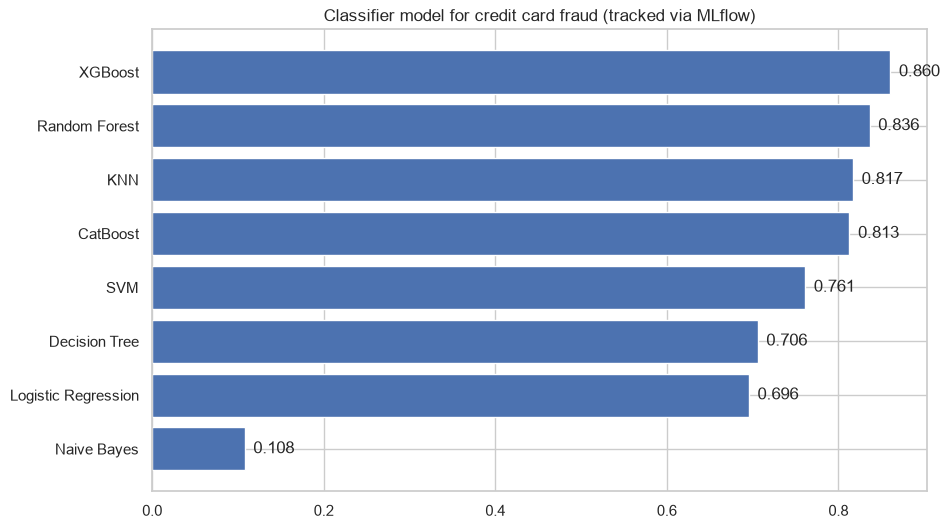

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

ordered = comparison.sort_values('F1')
ax.barh(ordered["tags.algorithm"], ordered["F1"])
ax.set_title("Classifier model for credit card fraud (tracked via MLflow)")
for i, v in enumerate(ordered["F1"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")

Training using Under Sampling in the pipeline 

In [24]:
run_ids = {}

for name, (ModelClass, params) in classifier.items():
    with mlflow.start_run(run_name=f'{name}_SMOTE_v1') as run:
        mlflow.set_tag('algorithm',name)
        mlflow.set_tag('sampling', 'SMOTE_V1')
        mlflow.log_params(params)

        #Build pipeline
        #scale -> smote -> fit in the loop
        model = ImbPipeline([
                ('preprocess', processor),
                ('smote', SMOTE(random_state=42)),
                ('classifier', ModelClass(**params))
            ])
        
        model.fit(x_train, y_train)

        preds = model.predict(x_test)
        proba = model.predict_proba(x_test)[:,1] if hasattr(model, 'predict_proba') else None

        metrics = {
            "accuracy": accuracy_score(y_test, preds),
            "precision": precision_score(y_test, preds),
            "recall": recall_score(y_test, preds),
            "F1": f1_score(y_test, preds)
        }

        if proba is not None:
            metrics['roc_auc'] = roc_auc_score(y_test, proba)
        
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(model, name='model',input_example=x_train[:2], skops_trusted_types=[
        "xgboost.core.Booster", 
        "xgboost.sklearn.XGBClassifier",
        "catboost.core.CatBoostClassifier",
        "catboost.CatBoostClassifier",
        "imblearn.over_sampling._smote.base.SMOTE",
        "imblearn.pipeline.Pipeline",
        "numpy.dtype"
        ])

        run_ids[name] = run.info.run_id
        print(f"{name:22s} run_id={run.info.run_id}  f1={metrics['F1']:.3f}  acc={metrics['accuracy']:.3f}")

2026/07/18 18:35:21 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:35:21 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:35:21 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/18 18:35:22 INFO mlflow.utils.uv_utils: Exported 181 dependencies via uv
2026/07/18 18:35:22 INFO mlflow.utils.environment: Successfully exported 181 requirements from uv project. Skipping package capture based inference.
2026/07/18 18:35:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Logistic Regression    run_id=6f7c83c164ae49c7bfbf005d45c734ef  f1=0.100  acc=0.974


2026/07/18 18:35:31 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:35:31 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:35:31 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/18 18:35:31 INFO mlflow.utils.uv_utils: Exported 181 dependencies via uv
2026/07/18 18:35:31 INFO mlflow.utils.environment: Successfully exported 181 requirements from uv project. Skipping package capture based inference.
2026/07/18 18:35:31 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Naive Bayes            run_id=a346a7b78bff486e90a3b3826d297943  f1=0.101  acc=0.976


2026/07/18 18:35:59 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:35:59 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:35:59 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/18 18:36:00 INFO mlflow.utils.uv_utils: Exported 181 dependencies via uv
2026/07/18 18:36:00 INFO mlflow.utils.environment: Successfully exported 181 requirements from uv project. Skipping package capture based inference.
2026/07/18 18:36:00 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Decision Tree          run_id=f88e14ec51874ac49165ab3e5e8e1cea  f1=0.506  acc=0.998


2026/07/18 18:37:08 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:37:08 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:37:08 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/18 18:37:08 INFO mlflow.utils.uv_utils: Exported 181 dependencies via uv
2026/07/18 18:37:08 INFO mlflow.utils.environment: Successfully exported 181 requirements from uv project. Skipping package capture based inference.
2026/07/18 18:37:08 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


KNN                    run_id=faa7baf896e84328951cf216ea4a69d9  f1=0.602  acc=0.998


2026/07/18 18:40:57 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:40:57 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:40:57 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/18 18:40:57 INFO mlflow.utils.uv_utils: Exported 181 dependencies via uv
2026/07/18 18:40:57 INFO mlflow.utils.environment: Successfully exported 181 requirements from uv project. Skipping package capture based inference.
2026/07/18 18:40:58 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Random Forest          run_id=164d22dd4e1d4877843551dd1028a443  f1=0.821  acc=0.999


2026/07/18 18:41:05 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:41:06 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:41:06 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/18 18:41:06 INFO mlflow.utils.uv_utils: Exported 181 dependencies via uv
2026/07/18 18:41:06 INFO mlflow.utils.environment: Successfully exported 181 requirements from uv project. Skipping package capture based inference.
2026/07/18 18:41:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


XGBoost                run_id=819bb414afa444a697b25001d5a05c35  f1=0.802  acc=0.999


2026/07/18 18:41:48 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:41:48 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:41:48 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/18 18:41:48 INFO mlflow.utils.uv_utils: Exported 181 dependencies via uv
2026/07/18 18:41:48 INFO mlflow.utils.environment: Successfully exported 181 requirements from uv project. Skipping package capture based inference.
2026/07/18 18:41:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


CatBoost               run_id=85119e8d49e7469a9f3852a8af3c5d85  f1=0.664  acc=0.999


In [25]:
#investigate first

experiment = mlflow.get_experiment_by_name("classification_for_credit_card_fraud")
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

metric_cols = [c for c in runs_df.columns if c.startswith("metrics.")]

comparison = runs_df[["run_id", "tags.algorithm","tags.sampling" ] + metric_cols].sort_values(
    "metrics.F1", ascending=False
).reset_index(drop=True)

comparison.columns= [c.replace("metrics.", "") for c in comparison.columns]
comparison = comparison[comparison["tags.sampling"] == 'SMOTE_V1']

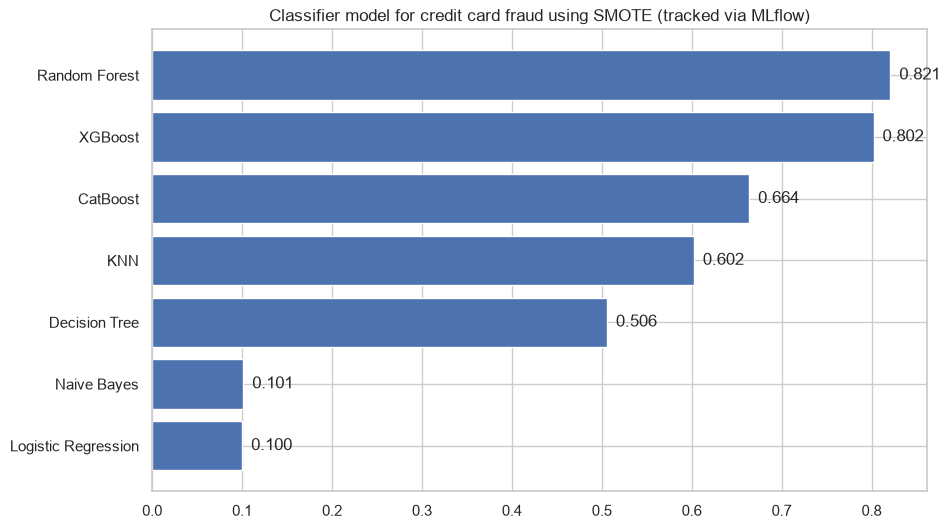

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

ordered = comparison.sort_values('F1')
ax.barh(ordered["tags.algorithm"], ordered["F1"])
ax.set_title("Classifier model for credit card fraud using SMOTE (tracked via MLflow)")
for i, v in enumerate(ordered["F1"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")

Under_sampling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler 
run_ids = {}

for name, (ModelClass, params) in classifier.items():
    with mlflow.start_run(run_name=f'{name}_under_sampling') as run:
        mlflow.set_tag('algorithm',name)
        mlflow.set_tag('sampling', 'undersampling')
        mlflow.log_params(params)

        #Build pipeline
        #scale -> smote -> fit in the loop
        model = ImbPipeline([
                ('preprocess', processor),
                ('undersampler', RandomUnderSampler(random_state=42)),
                ('classifier', ModelClass(**params))
            ])
        
        model.fit(x_train, y_train)

        preds = model.predict(x_test)
        proba = model.predict_proba(x_test)[:,1] if hasattr(model, 'predict_proba') else None

        metrics = {
            "accuracy": accuracy_score(y_test, preds),
            "precision": precision_score(y_test, preds),
            "recall": recall_score(y_test, preds),
            "F1": f1_score(y_test, preds)
        }

        if proba is not None:
            metrics['roc_auc'] = roc_auc_score(y_test, proba)
        
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(model, name='model',input_example=x_train[:2], skops_trusted_types=[
        "xgboost.core.Booster", 
        "xgboost.sklearn.XGBClassifier",
        "catboost.core.CatBoostClassifier",
        "catboost.CatBoostClassifier",
        "imblearn.over_sampling._smote.base.SMOTE",
        "imblearn.pipeline.Pipeline",
        "numpy.dtype",
        "imblearn.under_sampling._prototype_selection._random_under_sampler.RandomUnderSampler"
        ])

        run_ids[name] = run.info.run_id
        print(f"{name:22s} run_id={run.info.run_id}  f1={metrics['F1']:.3f}  acc={metrics['accuracy']:.3f}")

2026/07/18 18:47:50 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:47:50 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:47:50 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/18 18:47:50 INFO mlflow.utils.uv_utils: Exported 181 dependencies via uv
2026/07/18 18:47:50 INFO mlflow.utils.environment: Successfully exported 181 requirements from uv project. Skipping package capture based inference.
2026/07/18 18:47:50 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Logistic Regression    run_id=d475c93fce044d4786eafbdabbaf6e0a  f1=0.098  acc=0.973


2026/07/18 18:47:51 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:47:51 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:47:51 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/18 18:47:51 INFO mlflow.utils.uv_utils: Exported 181 dependencies via uv
2026/07/18 18:47:51 INFO mlflow.utils.environment: Successfully exported 181 requirements from uv project. Skipping package capture based inference.
2026/07/18 18:47:51 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Naive Bayes            run_id=465d21249b374b2592d14d110ed5a62c  f1=0.080  acc=0.969


2026/07/18 18:47:51 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:47:52 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:47:52 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/18 18:47:52 INFO mlflow.utils.uv_utils: Exported 181 dependencies via uv
2026/07/18 18:47:52 INFO mlflow.utils.environment: Successfully exported 181 requirements from uv project. Skipping package capture based inference.
2026/07/18 18:47:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Decision Tree          run_id=c0eb07f985f040cfb4b32b45264c7bc1  f1=0.028  acc=0.893


2026/07/18 18:47:52 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:47:52 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:47:52 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/18 18:47:52 INFO mlflow.utils.uv_utils: Exported 181 dependencies via uv
2026/07/18 18:47:52 INFO mlflow.utils.environment: Successfully exported 181 requirements from uv project. Skipping package capture based inference.
2026/07/18 18:47:53 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


KNN                    run_id=c57a1eb1e3fe4eb1920f65e7fe1416d3  f1=0.107  acc=0.976


2026/07/18 18:47:54 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:47:54 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:47:54 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/18 18:47:54 INFO mlflow.utils.uv_utils: Exported 181 dependencies via uv
2026/07/18 18:47:54 INFO mlflow.utils.environment: Successfully exported 181 requirements from uv project. Skipping package capture based inference.
2026/07/18 18:47:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Random Forest          run_id=818ac6013b794075a129b8022bb48149  f1=0.147  acc=0.983


2026/07/18 18:47:55 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:47:55 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:47:55 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/18 18:47:55 INFO mlflow.utils.uv_utils: Exported 181 dependencies via uv
2026/07/18 18:47:55 INFO mlflow.utils.environment: Successfully exported 181 requirements from uv project. Skipping package capture based inference.
2026/07/18 18:47:55 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


XGBoost                run_id=468a4ac0ea4c4087a386489026be4caf  f1=0.094  acc=0.972


2026/07/18 18:47:59 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:47:59 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection
2026/07/18 18:47:59 INFO mlflow.utils.environment: Detected uv project at c:\Users\Saad\Desktop\Credit-Card-Fraud-Detection. Attempting to export requirements via 'uv export'.
2026/07/18 18:47:59 INFO mlflow.utils.uv_utils: Exported 181 dependencies via uv
2026/07/18 18:47:59 INFO mlflow.utils.environment: Successfully exported 181 requirements from uv project. Skipping package capture based inference.
2026/07/18 18:47:59 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


CatBoost               run_id=5b61b68024934434abeb90813affc7a6  f1=0.141  acc=0.982


In [29]:
#investigate first

experiment = mlflow.get_experiment_by_name("classification_for_credit_card_fraud")
runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

metric_cols = [c for c in runs_df.columns if c.startswith("metrics.")]

comparison = runs_df[["run_id", "tags.algorithm","tags.sampling" ] + metric_cols].sort_values(
    "metrics.F1", ascending=False
).reset_index(drop=True)

comparison.columns= [c.replace("metrics.", "") for c in comparison.columns]
comparison = comparison[comparison["tags.sampling"] == 'undersampling']

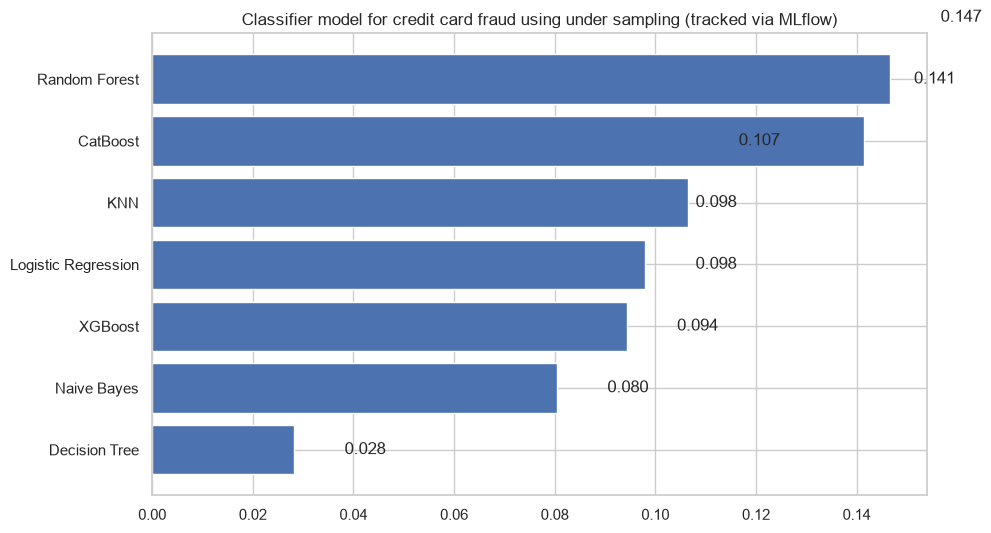

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))

ordered = comparison.sort_values('F1')
ax.barh(ordered["tags.algorithm"], ordered["F1"])
ax.set_title("Classifier model for credit card fraud using under sampling (tracked via MLflow)")
for i, v in enumerate(ordered["F1"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")